# CNN
Convolution is a fundamental operation in Convolutional Neural Networks (CNNs), which are specialized deep learning algorithms designed primarily for image and video analysis. CNNs are highly effective in tasks such as image classification, object detection, and segmentation.
CNNs consist of multiple layers like the input layer, Convolutional layer, pooling layer, and fully connected layers
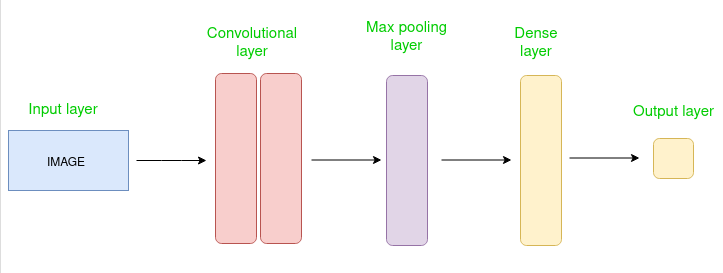
- **Convolutional Layer**: the foundational operation layer that extracts local features via kernels.
- **Kernel/Filter**: a sliding weight matrix (e.g., 3×3, 5×5) used for feature extraction.
- **Receptive Field(感受野)**: the input region affecting an output pixel, expanding with network depth.
- **Channel**: input data depth (e.g., 3 channels for RGB) or output feature map count.
- **Stride**: step size of kernel movement (e.g., stride 2 halves output dimensions).
- **Padding**: boundary zero-padding (same preserves size, valid discards edges).
- **Feature Map**: spatial feature representation output by convolution.
- **Transposed Convolution**: "Deconvolution" for upsampling (actually a backward-convolution pass).
- **Pooling Layer**: downsampling (e.g., max pooling, average pooling).
- **Global Average Pooling (GAP)**: reduces feature maps to 1×1, replacing fully connected layers.
- **Residual Block**: skip connections to mitigate vanishing gradients (ResNet).
- **Local Connectivity**: kernels connect only to local input regions (vs. DNN’s full connectivity).
- **Weight Sharing**: kernels reuse parameters globally, reducing computation.
- **Spatial Invariance**: CNN property: robustness to translation/rotation.

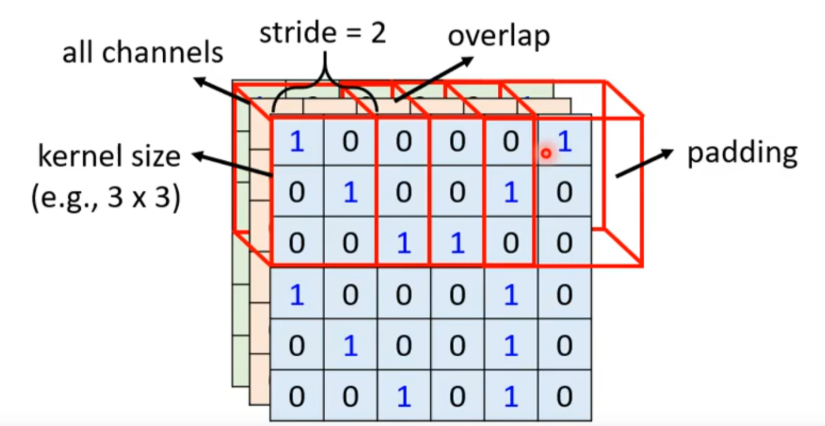

## Development
1990:LeNet-->2012:AlexNet（ReLU+Dropout）-->

2014:VGGNet(16~19 layers),GoogLeNet,R-CNN-->

2015:ResNet-->2016:DenseNet,YOLO,GAN-->

2017:Transformer-->2020:Vision Transformer


## AlexNet
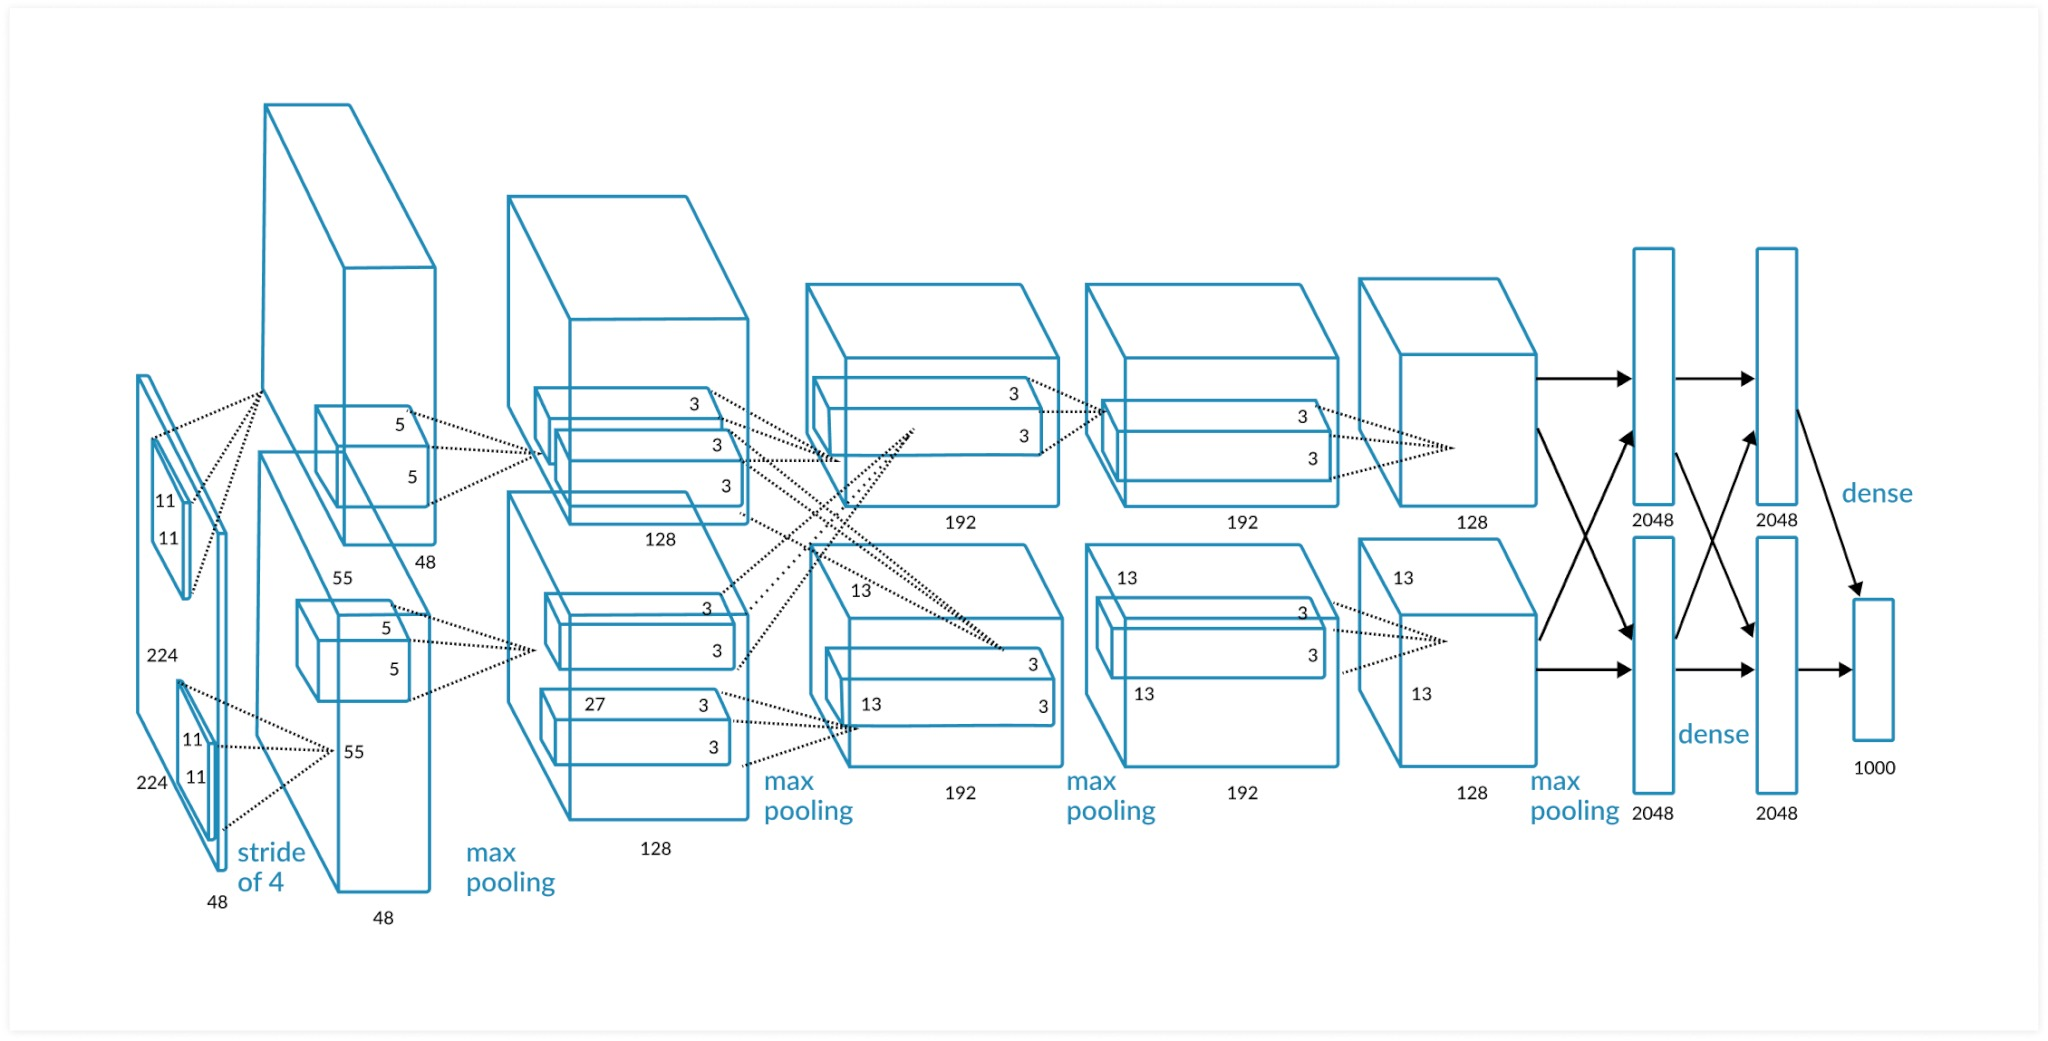
### Architecture Overview
- 8 layers deep (5 convolutional + 3 fully connected)

- Input size: 227×227×3 (RGB images)

- 60 million parameters (large for its time)

- ReLU activation (instead of Sigmoid/Tanh for faster training)

- Max Pooling (for downsampling)

- Dropout (to reduce overfitting in fully connected layers)

### Layers by Layers
|Layer	|Type	|Kernel Size	|Stride	|Output Size	|Activation|
|--	|---	|--	|--	|-- |--|
|Input| | 	| |227×227×3|  |
|Conv1	|Convolution	|11×11|	4	|55×55×96|	ReLU|
|Pool1	|Max Pooling	|3×3|	2	|27×27×96|	-|
|Conv2	|Convolution	|5×5|	1	|27×27×256	|ReLU|
|Pool2	|Max Pooling	|3×3|	2	|13×13×256	|-|
|Conv3	|Convolution	|3×3|	1	|13×13×384	|ReLU|
|Conv4	|Convolution	|3×3|	1	|13×13×384	|ReLU|
|Conv5	|Convolution	|3×3|	1	|13×13×256	|ReLU|
|Pool5	|Max Pooling	|3×3|	2	|6×6×256	|-|
|FC6	|Fully Connected|	-	|-	|4096	|ReLU|
|FC7	|Fully Connected|	-	|-	|4096	|ReLU|
|FC8	|Fully Connected|	-	|-	|1000 (ImageNet classes)|	Softmax|


### Calculation
$$
W_{output} = \lfloor \frac{W_{in}+2Padding-W_{kernel}}{Stride}\rfloor+1
$$


$$
H_{output} = \lfloor \frac{H_{in}+2Padding-H_{kernel}}{Stride}\rfloor+1
$$

### pytorch method 
> torch.nn.Conv2d(in_channels, out_channels, kernel_size, stride=1, padding=0, dilation=1, groups=1, bias=True, padding_mode='zeros', device=None, dtype=None)

When groups == in_channels and out_channels == K * in_channels, where K is a positive integer, this operation is also known as a “depthwise convolution”.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [2]:
# Set random seeds
np.random.seed(42)
torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load and prepare data
digits = load_digits()
X, y = digits.images, digits.target
X = X.reshape(-1, 1, 8, 8) / 16.0  # Normalize

# Convert to tensors
X_tensor = torch.FloatTensor(X)
y_tensor = torch.LongTensor(y)
X_train, X_test, y_train, y_test = train_test_split(
    X_tensor, y_tensor, test_size=0.2, random_state=42
)

# Create data loaders
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=32, shuffle=False)

In [3]:
# Define CNN model
class SimpleCNN(nn.Module):
    def __init__(self, filters=32, dropout=0.3):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, filters, 3, padding=1)
        self.conv2 = nn.Conv2d(filters, filters*2, 3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(filters*2 * 2 * 2, 64)  # 8->4->2
        self.fc2 = nn.Linear(64, 10)
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)



In [4]:
# Training function
def train(model, epochs=20, lr=0.001):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    train_accs, test_accs = [], []
    
    for epoch in range(epochs):
        # Train
        model.train()
        correct, total = 0, 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            
            _, predicted = torch.max(outputs, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()
        train_accs.append(correct / total)
        
        # Test
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                _, predicted = torch.max(outputs, 1)
                total += y_batch.size(0)
                correct += (predicted == y_batch).sum().item()
        test_accs.append(correct / total)
        
        if (epoch + 1) % 5 == 0:
            print(f'Epoch {epoch+1}/{epochs} | Train Acc: {train_accs[-1]:.3f} | Test Acc: {test_accs[-1]:.3f}')
    
    return train_accs, test_accs



Experiment 1: Varying number of filters

Training with 8 filters...
Epoch 5/15 | Train Acc: 0.749 | Test Acc: 0.881
Epoch 10/15 | Train Acc: 0.887 | Test Acc: 0.928
Epoch 15/15 | Train Acc: 0.922 | Test Acc: 0.969

Training with 16 filters...
Epoch 5/15 | Train Acc: 0.813 | Test Acc: 0.900
Epoch 10/15 | Train Acc: 0.903 | Test Acc: 0.961
Epoch 15/15 | Train Acc: 0.940 | Test Acc: 0.972

Training with 32 filters...
Epoch 5/15 | Train Acc: 0.871 | Test Acc: 0.942
Epoch 10/15 | Train Acc: 0.949 | Test Acc: 0.986
Epoch 15/15 | Train Acc: 0.971 | Test Acc: 0.989

Training with 64 filters...
Epoch 5/15 | Train Acc: 0.922 | Test Acc: 0.969
Epoch 10/15 | Train Acc: 0.974 | Test Acc: 0.989
Epoch 15/15 | Train Acc: 0.987 | Test Acc: 0.997

Experiment 2: Varying dropout rates

Training with dropout=0.0...
Epoch 5/15 | Train Acc: 0.951 | Test Acc: 0.947
Epoch 10/15 | Train Acc: 0.972 | Test Acc: 0.978
Epoch 15/15 | Train Acc: 0.994 | Test Acc: 0.994

Training with dropout=0.3...
Epoch 5/15 | Train

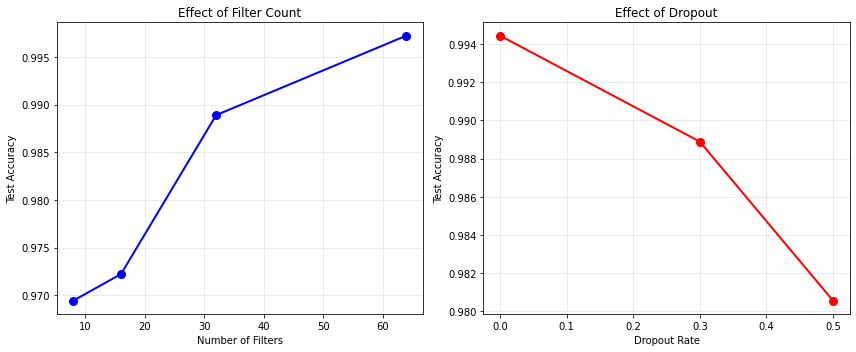


Training final model with optimal parameters...
Epoch 5/30 | Train Acc: 0.873 | Test Acc: 0.939
Epoch 10/30 | Train Acc: 0.936 | Test Acc: 0.983
Epoch 15/30 | Train Acc: 0.965 | Test Acc: 0.989
Epoch 20/30 | Train Acc: 0.985 | Test Acc: 0.994
Epoch 25/30 | Train Acc: 0.989 | Test Acc: 0.994
Epoch 30/30 | Train Acc: 0.986 | Test Acc: 0.997


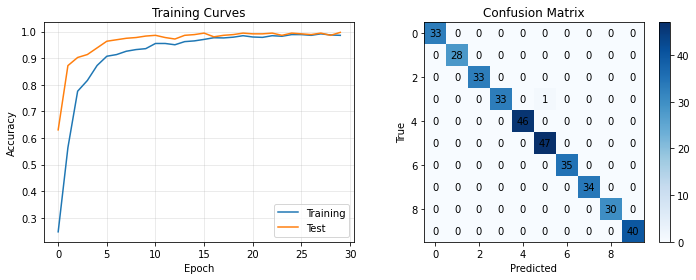


Final Test Accuracy: 0.9972


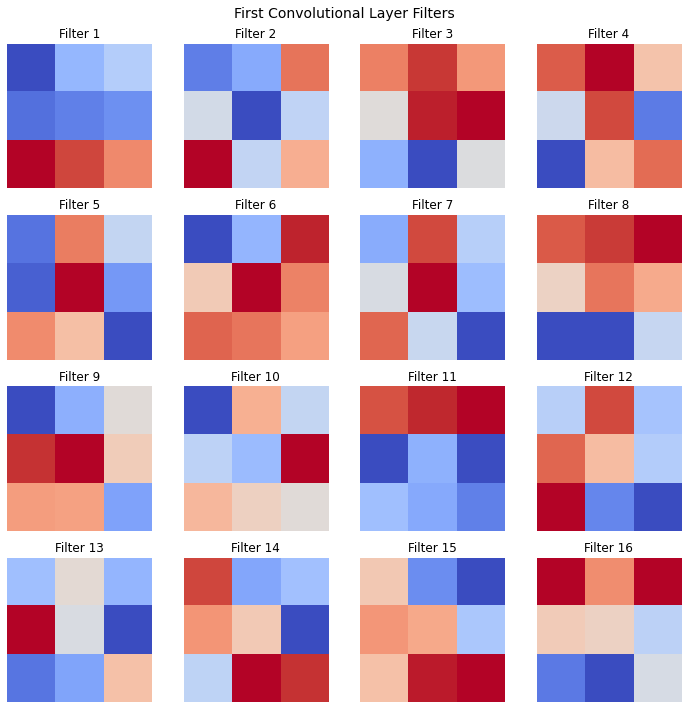

In [5]:
# Experiment 1: Different filter sizes
print("="*40)
print("Experiment 1: Varying number of filters")
filter_sizes = [8, 16, 32, 64]
filter_results = []

for f in filter_sizes:
    print(f"\nTraining with {f} filters...")
    model = SimpleCNN(filters=f)
    _, test_accs = train(model, epochs=15)
    filter_results.append(test_accs[-1])

# Experiment 2: Different dropout rates
print("\n" + "="*40)
print("Experiment 2: Varying dropout rates")
dropouts = [0.0, 0.3, 0.5]
dropout_results = []

for d in dropouts:
    print(f"\nTraining with dropout={d}...")
    model = SimpleCNN(dropout=d)
    _, test_accs = train(model, epochs=15)
    dropout_results.append(test_accs[-1])

# Plot results
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Filter size effect
axes[0].plot(filter_sizes, filter_results, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Filters')
axes[0].set_ylabel('Test Accuracy')
axes[0].set_title('Effect of Filter Count')
axes[0].grid(True, alpha=0.3)

# Dropout effect
axes[1].plot(dropouts, dropout_results, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Dropout Rate')
axes[1].set_ylabel('Test Accuracy')
axes[1].set_title('Effect of Dropout')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Train final best model
print("\n" + "="*40)
print("Training final model with optimal parameters...")
best_model = SimpleCNN(filters=32, dropout=0.3)
train_accs, test_accs = train(best_model, epochs=30)

# Plot training curves
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(train_accs, label='Training')
plt.plot(test_accs, label='Test')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Curves')
plt.legend()
plt.grid(True, alpha=0.3)

# Confusion matrix
plt.subplot(1, 2, 2)
best_model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = best_model(X_batch)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y_batch.numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar()
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')

# Add text annotations
for i in range(10):
    for j in range(10):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center')

plt.tight_layout()
plt.show()

print(f"\nFinal Test Accuracy: {test_accs[-1]:.4f}")

# Visualize filters
plt.figure(figsize=(10, 10))
filters = best_model.conv1.weight.data.cpu().numpy()
for i in range(min(16, filters.shape[0])):
    plt.subplot(4, 4, i+1)
    plt.imshow(filters[i, 0], cmap='coolwarm')
    plt.title(f'Filter {i+1}')
    plt.axis('off')
plt.suptitle('First Convolutional Layer Filters', fontsize=14)
plt.tight_layout()
plt.show()

### Reference
- https://www.cnblogs.com/awei040519/articles/18544328